In [14]:
import os
import tensorflow as tf
import seaborn as sns
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("float32")
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense,Activation,Dropout,Conv2D,MaxPooling2D,BatchNormalization,Flatten
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model, load_model, Sequential
from sklearn.metrics import confusion_matrix, classification_report
from mlxtend.plotting import plot_confusion_matrix
import itertools
import matplotlib.pyplot as plt
import datetime
import matplotlib.image as mping
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd

In [17]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dir = "C:/Users/Harsh Sakhare/Downloads/lp5/DL/plant disease dataset"

train_data = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    batch_size=16,
    image_size=(128,128)
)

val_data = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    batch_size=16,
    image_size=(128,128)
)

Found 34049 files belonging to 22 classes.
Using 27240 files for training.
Found 34049 files belonging to 22 classes.
Using 6809 files for validation.


In [18]:
class_names=train_data.class_names
class_count=len(class_names)
class_count

22

In [19]:
samples = []
x = 0
for i in tqdm(train_data.unbatch()):
    if (x == 10):
        break
    samples.append([i[0], i[1]])
    x += 1

0it [00:00, ?it/s]

In [20]:
images = []
labels = []

for imgs, lbls in samples:
    images.append(imgs)
    labels.append(class_names[lbls.numpy()])

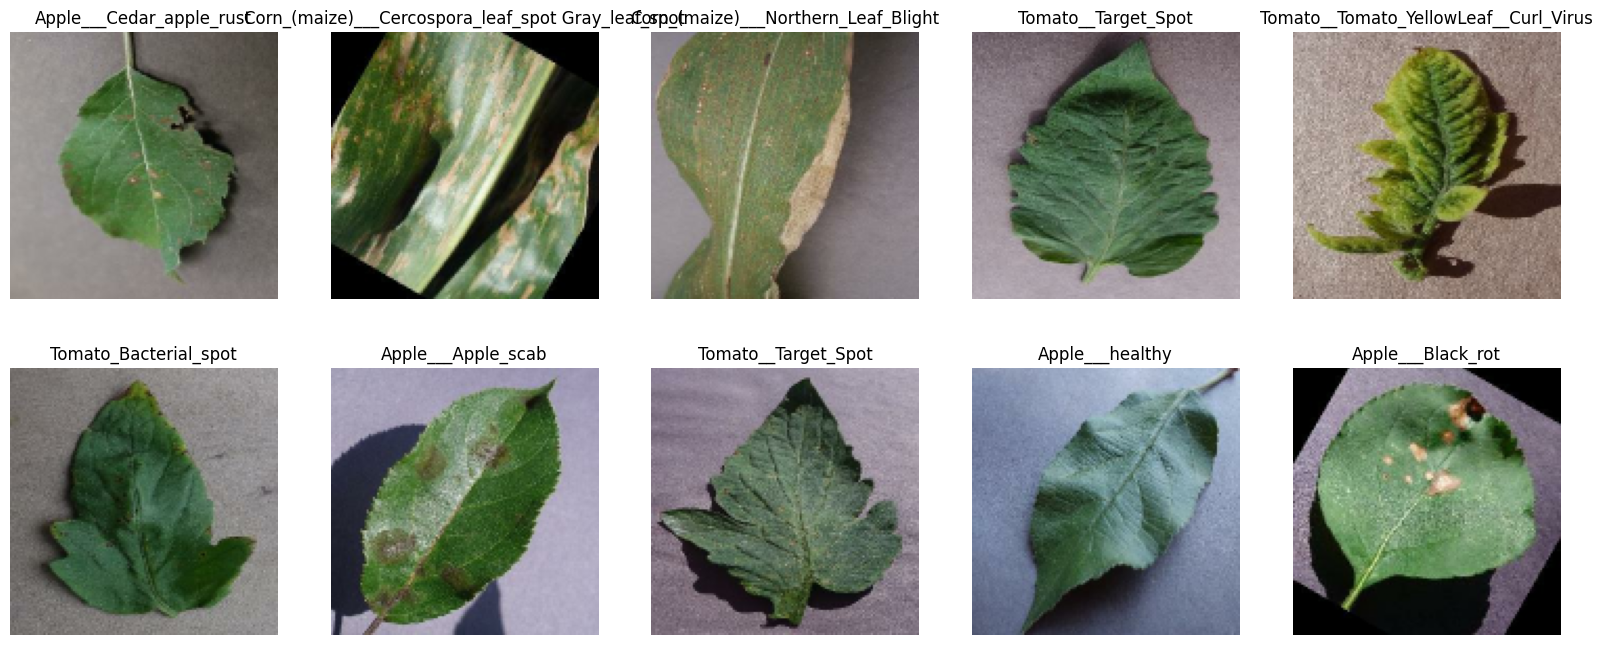

In [21]:
fig = plt.figure(figsize=(20, 8))
rows = 2
cols = 5
x = 1
for image, label in zip(images, labels):
    fig.add_subplot(rows, cols, x)
    plt.imshow(image/255.)
    plt.axis("off")
    plt.title(label)
    x += 1

In [22]:
input_shape = (128, 128, 3)

In [23]:
def create_early_stopper():
    earlystopper = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                    patience=3,
                                                    restore_best_weights=True,
                                                    min_delta=0.001,
                                                    verbose=1)
    return earlystopper

In [24]:
model_name = 'EfficientNetB0'
# 1. Base model
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(128,128,3),
    pooling='max'
)

base_model.trainable = False

# 2. Custom layers
x = base_model.output
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.45)(x)
output = tf.keras.layers.Dense(class_count, activation='softmax')(x)

# 3. Create model
model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

# 4. THEN compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
x = base_model.output

x = tf.keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.002)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.45, seed=42)(x)
output = Dense(class_count, activation='softmax')(x)

model=Model(inputs=base_model.input, outputs=output)
model.compile(tf.keras.optimizers.Adam(learning_rate=0.00001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [26]:
early_stopper = tf.keras.callbacks.EarlyStopping(patience=5, min_delta=0.01, verbose=1)

In [27]:
history = model.fit(train_data,
                    epochs=3,
                    validation_data=val_data,  
                    callbacks=[early_stopper]
                   )

Epoch 1/3
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 191s 108ms/step - accuracy: 0.1703 - loss: 3.1765 - val_accuracy: 0.4804 - val_loss: 1.8803
Epoch 2/3
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 191s 112ms/step - accuracy: 0.4054 - loss: 2.0716 - val_accuracy: 0.6434 - val_loss: 1.3122
Epoch 3/3
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 200s 117ms/step - accuracy: 0.5096 - loss: 1.6522 - val_accuracy: 0.7174 - val_loss: 1.0271


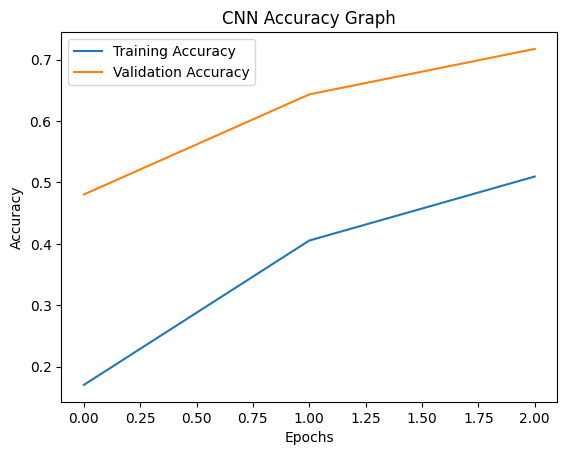

In [28]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()